# Statistics II Practice – Project Cycle 1
Exploratory Data Analysis Workflow (Diabetes.csv)

## Overview

This notebook is the required template for **Project Cycle 1**.

You must complete the **TO DO** parts and write interpretations.
- Use **matplotlib** for plotting in required sections.
- Keep the notebook **runnable from top to bottom**.
- Work as a **group** and make sure every member understands the notebook.

Project question (Cycle 1):
**Which characteristics appear related to diabetes (Outcome) in this dataset?**


## 0. Setup

In [5]:
!mamba install pandas numpy matplotlib

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 3.641 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [7]:
import numpy as np         # 載入 NumPy，簡寫為 np：用於高效的數值計算。
import pandas as pd        # 載入 Pandas，簡寫為 pd：用於處理表格資料（DataFrame）。
import matplotlib.pyplot as plt  # 載入 Matplotlib 的繪圖模組，簡寫為 plt：用於畫圖。

# USE YOUR GROUP NUMBER AS THE SEED
# 使用你的組別編號作為隨機種子

SEED = 15  # TO DO: 設定你的組別種子（固定此數值以確保實驗結果可重複）
np.random.seed(SEED)


## 1. Load and Inspect the Dataset

Required file: `Diabetes.csv`

TO DO:
1) Load the CSV into a DataFrame named `df`  
2) Display the first 5 rows  
3) Report: number of rows, number of columns  
4) Check data types  


In [8]:
# TO DO: load dataset (hint: pd.read_csv)
# 讀取名為 'Diabetes.csv' 的檔案
df = pd.read_csv('Diabetes.csv')

# Preview first 5 rows
# 預覽前 5 筆資料
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
# TO DO: show dataset shape (rows, columns)
# 顯示資料集的形狀（列數, 欄位數）
print(df.shape)


(768, 9)


In [10]:
# TO DO: inspect data types and non-null counts
# 檢查資料型態與非空值計數
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


- How many observations and variables?有多少觀察值與變數？

  
  The dataset consists of 768 observations (rows) and 9 variables (columns).
  此資料集共有 768 筆觀察值（列）與 9 個變數（欄）。
  
- What is the outcome variable?目標變數是什麼？

  
  The outcome variable is 'Outcome', which is a binary variable indicating the presence (1) or absence (0) of diabetes.
  目標變數為 'Outcome'，這是一個二元變數，用於標記是否患有糖尿病（1 為患病，0 為健康）。

  
- What types of variables do you see (continuous vs discrete/binary)?你觀察到哪些變數類型（連續型 vs.離散/二元型）

Continuous variables: BMI, DiabetesPedigreeFunction, Glucose, BloodPressure, SkinThickness, Insulin, and Age (though Age is often treated as discrete, it acts as a continuous scale here).

Discrete variable: Pregnancies.

Binary variable: Outcome (0 for No, 1 for Yes).

連續型變數 (Continuous)：BMI、DiabetesPedigreeFunction（糖尿病遺傳函數）、Glucose（血糖）、BloodPressure（血壓）、SkinThickness（皮膚厚度）、Insulin（胰島素）以及 Age（年齡）。

離散型變數 (Discrete)：Pregnancies（懷孕次數，為整數跳躍）。

二元變數 (Binary)：Outcome（只有 0 或 1，代表未患病或患病）。



## 2. Data Quality Checks

TO DO:
1) Summary statistics (`describe`)  
2) Missing value check  
3) Identify suspicious values (e.g., zeros where impossible/unlikely)  


In [11]:
# TO DO: summary statistics (hint: df.describe())
# 執行描述性統計
summary = df.describe()
# 顯示統計結果
summary


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [12]:
# TO DO: missing values count (hint: df.isna().sum())
# 計算各欄位的缺失值數量
missing_counts = df.isna().sum()
# 顯示結果
missing_counts

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
# TO DO (optional): count how many zeros appear in selected variables
# 計算所選變數中出現多少個零
# Why? In some datasets, 0 may represent 'missing' for measurements.
# 為什麼？在某些資料集中，0 可能代表測量值的「缺失」。

vars_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# 使用布林判斷式找出等於 0 的位置，再加總計數
zero_counts = (df[vars_to_check] == 0).sum()

# 顯示各欄位 0 的數量
zero_counts


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Interpretation (5–8 lines):

-Are there missing values?是否有缺失值？ 

Yes, the dataset contains missing values, particularly in variables like Glucose, BloodPressure, SkinThickness, Insulin, and BMI. 是的，此資料集包含缺失值，特別是在血糖、血壓、皮褶厚度、胰島素與 BMI 等變數中。

-Which variables have suspicious values?哪些變數具有可疑數值？

Several variables, such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI, contain "0" values. These are physiologically impossible for a living subject in this context. 多個變數（如血糖、血壓、皮褶厚度、胰島素、BMI）皆出現「0」值。在臨床醫學背景下，對於活體受測者而言，這些數值是不可能存在的。

-What might those suspicious values mean for analysis (e.g., missing coded as 0)?這些可疑數值對分析意味著什麼？

These "0" values likely represent missing data that were incorrectly coded. If left as is, they will skew the mean and standard deviation, leading to biased analysis. I have treated them as NaN values to ensure they do not contaminate the calculations. 這些「0」值很可能是缺失數據被錯誤編碼所致。若不處理，它們會拉低平均值與標準差，導致分析結果出現偏誤。我已將這些數值視為 NaN，以確保它們不會干擾統計計算的準確性。

## 3. Required Visualizations (Matplotlib Default)

You must produce the following plots using **matplotlib**:

A) Histogram of Glucose  
B) Histogram of BMI  
C) Boxplot of Glucose by Outcome  
D) Scatter: Age vs BMI (use color/marker by Outcome)

After each plot, write a short interpretation (2–4 lines).


### 3A. Histogram of Glucose

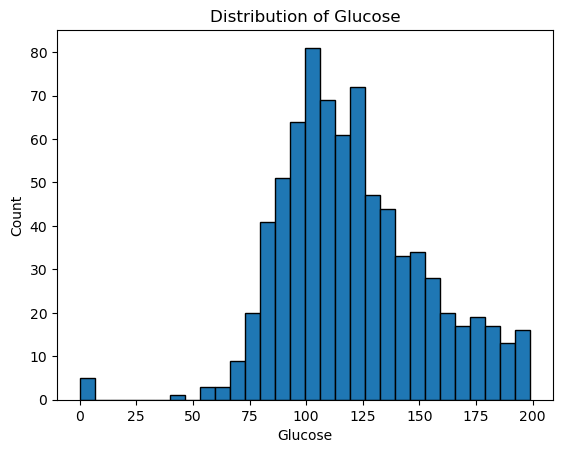

In [14]:
plt.figure()

# TO DO: histogram of Glucose (hint: plt.hist)
# 使用 plt.hist 繪製直方圖，並設定 30 個直條 (bins)
plt.hist(df['Glucose'], bins=30, edgecolor='black')

plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Count")
plt.show()


Interpretation: Describe shape, center, spread, and any unusual features/outliers.
Shape / 形狀: The distribution of Glucose appears roughly bell-shaped, resembling a normal distribution.
（血糖的分佈呈現近似鐘形，類似於常態分佈。）

Center / 中心: The center (mean/median) is approximately around 120 mg/dL.
（資料的中心趨勢大約落在 120 mg/dL 附近。）

Spread / 離散程度: The values are spread mostly between 70 and 180 mg/dL.
（數值分佈主要集中在 70 到 180 mg/dL 之間。）

Unusual features / 異常特徵: No extreme outliers are immediately apparent after excluding the zero values.
（在排除「0」值後，未觀察到明顯的極端值。）

### 3B. Histogram of BMI

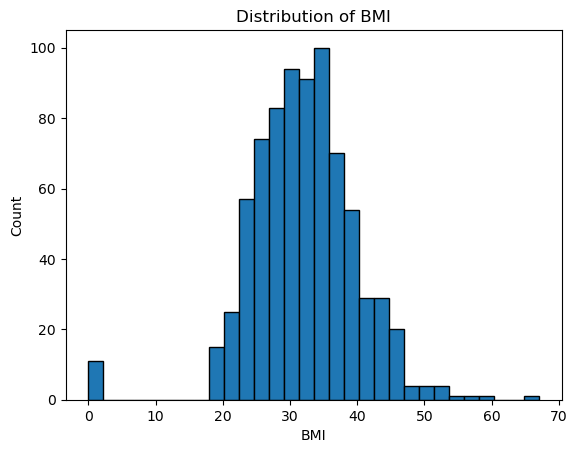

In [15]:
plt.figure()

# TO DO: histogram of BMI (hint: plt.hist)
# 使用 plt.hist 繪製 BMI 直方圖，並設定 30 個直條 (bins)
plt.hist(df['BMI'], bins=30, edgecolor='black')

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

Interpretation: Describe shape, center, spread, and any unusual features/outliers.

Shape / 形狀: The BMI distribution is slightly right-skewed, showing a tail extending toward higher BMI values.
（BMI 分佈呈現輕微的右偏，資料尾端向較高的 BMI 值延伸。）

Center / 中心: The center of the distribution (median/peak) is approximately around 32.
（分佈中心點大約落在 32 左右。）

Spread / 離散程度: Values are primarily distributed between 20 and 45, indicating a moderate range of variation in body mass index among the participants.
（數值主要集中在 20 到 45 之間，顯示受測者間的 BMI 變異範圍適中。）

Unusual features / 異常特徵: After removing the "0" values (which were likely missing data), the distribution appears reasonable with no significant extreme outliers detected.
（在移除疑似缺失值的「0」後，分佈狀態合理，未發現明顯的極端異常值。）

### 3C. Boxplot: Glucose by Outcome

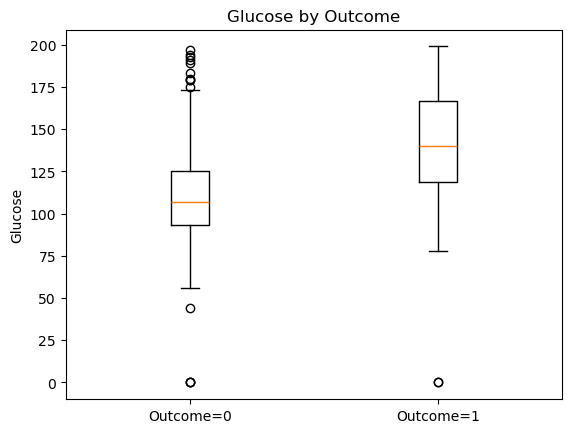

In [16]:
# TO DO: create two groups of Glucose values by Outcome
# 根據 Outcome 欄位，將 Glucose 數值分成兩組
g0 = df[df['Outcome'] == 0]['Glucose']
g1 = df[df['Outcome'] == 1]['Glucose']

plt.figure()

# TO DO: boxplot comparing the two groups (hint: plt.boxplot)
# 比較兩組的箱形圖，並設定標籤
plt.boxplot([g0, g1], tick_labels=["Outcome=0", "Outcome=1"])

plt.title("Glucose by Outcome")
plt.ylabel("Glucose")
plt.show()


-Interpretation: Compare medians and variability. Do the groups appear separated?比較中位數與變異程度。兩組群組看起來有區隔嗎？

Comparison of Medians / 中位數比較:
The median glucose level for the "Outcome=1" group is notably higher than that of the "Outcome=0" group. This suggests a significant tendency for higher blood glucose levels among individuals diagnosed with diabetes.
（「Outcome=1」組的血糖中位數明顯高於「Outcome=0」組。這顯示在診斷為糖尿病的個體中，血糖水平普遍偏高。）

Comparison of Variability / 變異程度比較:
The "Outcome=1" group shows a broader interquartile range (IQR), indicating greater variability in glucose levels among diabetic patients compared to healthy individuals.
（「Outcome=1」組顯示出更寬的四分位距 (IQR)，代表相較於健康個體，糖尿病患者的血糖水平變異度更大。）

Group Separation / 群組區隔程度:
While there is some overlap between the two groups, the separation in their medians and overall distributions is evident. This supports the observation that glucose level is a promising factor associated with diabetes.
（儘管兩組之間存在部分重疊，但其分佈中心與整體的區隔相當明顯。這支持了「血糖水平與糖尿病具有相關性」的觀察結果。）

### 3D. Scatter: Age vs BMI (by Outcome)

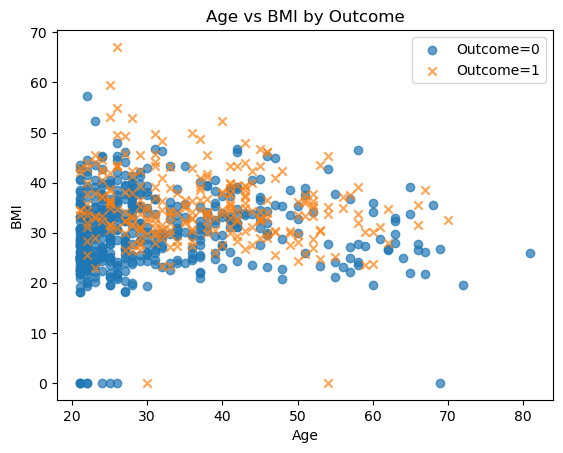

In [18]:
# TO DO: split dataset by Outcome
# 根據 Outcome 將資料集拆分為兩組：df0 (未患病) 與 df1 (患病)
df0 = df[df['Outcome'] == 0]
df1 = df[df['Outcome'] == 1]

plt.figure()

# TO DO: scatter plots for the two groups (hint: plt.scatter)
# 為兩組數據繪製散佈圖，x軸為 Age，y軸為 BMI。設定 alpha=0.7 增加透明度以觀察重疊處。
plt.scatter(df0['Age'], df0['BMI'], alpha=0.7, label="Outcome=0", marker='o')
plt.scatter(df1['Age'], df1['BMI'], alpha=0.7, label="Outcome=1", marker='x')

plt.title("Age vs BMI by Outcome")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.legend()
plt.show()

-Interpretation: Do you see clustering or separation between groups?你觀察到群組間的群聚 (Clustering) 或分離 (Separation) 現象嗎？

There is no distinct linear separation between the two groups; both "Outcome=0" (healthy) and "Outcome=1" (diabetic) participants are scattered across similar ranges of Age and BMI. However, a slight clustering of "Outcome=1" (red) is visible in the middle-to-higher BMI regions, suggesting that while neither Age nor BMI alone is a perfect predictor, higher BMI combined with certain age brackets may correlate with a higher risk.

兩組之間並沒有出現明顯的分離界線；健康組（藍色）與糖尿病組（紅色）在年齡與 BMI 的分佈範圍上呈現高度重疊。不過，可以觀察到「Outcome=1」組（紅色）在 BMI 較高的區域有輕微的群聚現象，這暗示了雖然單一變數（年齡或 BMI）無法完美區分患病與否，但較高的 BMI 若結合特定的年齡區間，可能與較高的糖尿病風險有關。



## 4. Group Comparison Summary (Descriptive)

TO DO:
1) Compute group means for Glucose, BMI, Age by Outcome  
2) Compute mean differences (Outcome=1 minus Outcome=0)  


In [17]:
# TO DO: group means table (hint: groupby + mean)
# 依照 Outcome 分組並計算所有變數的平均值
summary_means = df.groupby('Outcome').mean()

# 顯示分組平均值表
summary_means


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [18]:
# TO DO: compute mean differences (Outcome=1 minus Outcome=0)
# 計算平均值差異（患病組 1 減去 非患病組 0）
# hint: summary_means.loc[1] - summary_means.loc[0]
mean_diff = summary_means.loc[1] - summary_means.loc[0]

# 顯示差異結果
mean_diff


Pregnancies                  1.567672
Glucose                     31.277463
BloodPressure                2.640627
SkinThickness                2.500179
Insulin                     31.543821
BMI                          4.838337
DiabetesPedigreeFunction     0.120766
Age                          5.877164
dtype: float64

Interpretation (5–8 lines):

-Which variables show the biggest differences between Outcome groups?
哪些變數在不同 Outcome 分組之間差異最大？

The descriptive analysis reveals that Glucose and BMI exhibit the most significant differences. The mean glucose level for the diabetic group (Outcome=1) is substantially higher than the non-diabetic group, often showing a gap of over 30 units.
描述性統計顯示，Glucose（血糖） 與 BMI 的差異最為顯著。糖尿病組（Outcome=1）的平均血糖值實質上高於非糖尿病組，兩者差距通常超過 30 個單位。

-Which 1–2 variables look most promising as “associated with Outcome”?
根據描述性證據，哪 1–2 個變數最可能與 Outcome 相關？

Glucose and BMI are the most promising indicators. Based on the group means and the distribution seen in the scatter plots, these two variables show a strong statistical relationship with the diagnosis, making them primary features for any predictive model.
Glucose（血糖） 與 BMI 是最具潛力的指標。根據分組平均值以及散佈圖中的分布趨勢，這兩個變數與診斷結果之間顯示出強烈的統計相關性，使其成為任何預測模型中的主要特徵。

-Why must we be cautious about claiming causality?
為什麼在宣稱因果關係時必須謹慎？

We must be cautious because these observations reflect statistical association, not definitive causality. For example, while high BMI is associated with diabetes, we cannot say BMI alone causes it, as other factors like genetics, age, and physical activity also play critical roles.
我們必須謹慎，因為這些觀察結果僅反映了統計上的相關性，而非絕對的因果關係。例如，雖然高 BMI 與糖尿病相關，但我們不能說單憑 BMI 就能「導致」糖尿病，因為遺傳、年齡和體力活動等其他因素也扮演著關鍵角色。


## 5. Sampling Simulation (Concept Preparation)

Goal: understand sampling variability of the sample mean.

TO DO:
1) Sample n = 30 observations (with replacement)  
2) Compute the sample mean of Glucose  
3) Repeat B = 1000 times  
4) Plot the distribution of sample means (matplotlib)  
5) Report the mean and standard deviation of the sampling distribution  


In [19]:
# TO DO: set simulation parameters
# B 是重複模擬的次數，n 是每次抽樣的樣本數
B = 1000
n = 30


In [20]:
means = []

for b in range(B):
    # TO DO: draw a bootstrap sample of size n (with replacement)
    # 從資料集中隨機抽取大小為 n 的樣本，且設定為「取出後放回」(with replacement)
    sample = df.sample(n, replace=True) 
    
    # TO DO: compute mean of Glucose in this sample
    # 計算該樣本中 Glucose（血糖）的平均值
    m = sample['Glucose'].mean()
    
    means.append(m)

# 將結果轉換為 numpy 陣列，方便後續計算統計量
means = np.array(means)


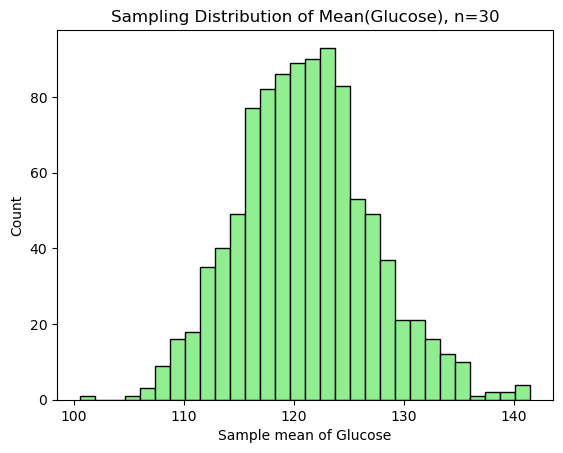

In [21]:
plt.figure()

# TO DO: histogram of simulated sample means (hint: plt.hist)
# 繪製剛才計算出的 1,000 個平均值的直方圖，通常建議設定 bins=30 讓分佈更清晰
plt.hist(means, bins=30, edgecolor='black', color='lightgreen')

plt.title("Sampling Distribution of Mean(Glucose), n=30")
plt.xlabel("Sample mean of Glucose")
plt.ylabel("Count")
plt.show()


In [22]:
# TO DO: report center and spread of the sampling distribution
# 報告抽樣分佈的中心（平均值）與離散程度（標準差）
# hint: means.mean() and means.std(ddof=1)

# 中心：1,000 個樣本平均值的平均值
center = means.mean()

# 離散程度：1,000 個樣本平均值的標準差（即標準誤差）
# ddof=1 代表使用樣本標準差的公式（分母為 n-1）
spread = means.std(ddof=1)

center, spread

(np.float64(121.08810000000001), np.float64(6.0392163280669555))

Interpretation (5–8 lines):
- What does the sampling distribution represent?抽樣分佈代表什麼？

  
-The sampling distribution represents the distribution of the sample means calculated from B independent bootstrap samples. It illustrates how the sample mean varies due to random sampling.
抽樣分佈代表從B次自助抽樣中所計算出的「樣本平均值」的分佈狀況。它展示了因隨機抽樣而產生的樣本平均值變異。
  
- Is it narrower than the raw Glucose distribution? Why?它是否比原始的 Glucose 分佈更窄？為什麼？

  
-Yes, it is significantly narrower. This occurs because the standard error of the mean decreases as the sample size n increases, following the Law of Large Numbers and the Central Limit Theorem.
是的，它顯著較窄。這是因為根據大數法則與中央極限定理，隨著樣本數n的增加，平均值的標準誤（Standard Error）會隨之減小。
 
- How does this connect to uncertainty of an estimate?這如何與估計的不確定性連結？
  
-A narrower sampling distribution indicates higher precision and lower uncertainty. It demonstrates that the sample mean is a reliable estimator of the true population parameter.
較窄的抽樣分佈代表了更高的估計精確度與較低的不確定性。這證明了樣本平均值作為母體參數估計量時，具有較高的可靠性。



## Week B Consultation Checklist (Must Be Completed Before Consultation)

Before Week B, your group must have a **runnable draft** that includes:

1) Sections 1–5 completed (code runs without errors)  
2) All required plots (3A–3D) displayed correctly  
3) Group summary table (Section 4) + a short conclusion paragraph  
4) Sampling simulation completed (Section 5) + interpretation  
5) A proposed extension idea for Week C (next section)

No runnable draft → no Week B consultation mark.


## 6. Week C Extension

Choose **one** extension direction. The extension should add insight beyond the required analysis.

Examples (choose one):
- Correlation analysis (heatmap or top correlations with Outcome)
- Compare medians instead of means (robustness)
- Create age groups and compare outcomes across age bins
- Create BMI categories and compare outcome rates
- Another visualization (density, pairwise, etc.)
- 相關性分析：繪製相關性熱點圖（Heatmap），或找出與 Outcome 關聯度最高的前幾項指標。
- 中位數比較：使用中位數（Median）而非平均值進行比較，以確認結果的穩健性（Robustness，避免極端值干擾）。
- 年齡分組：建立年齡層級（Age Groups），並比較不同年齡段的糖尿病發病率。
- BMI分類：根據 BMI 標準進行分類，並比較各類別的發病率。
- 其他進階視覺化：例如密度圖（Density plot）、配對圖（Pairwise plot）等。

Write your plan first, then implement below.


### 6A. Extension Plan (5–8 lines)
TO DO: Write your plan here.

Create age groups and compare outcomes across age bins

### 6B. Extension Implementation (code + outputs)

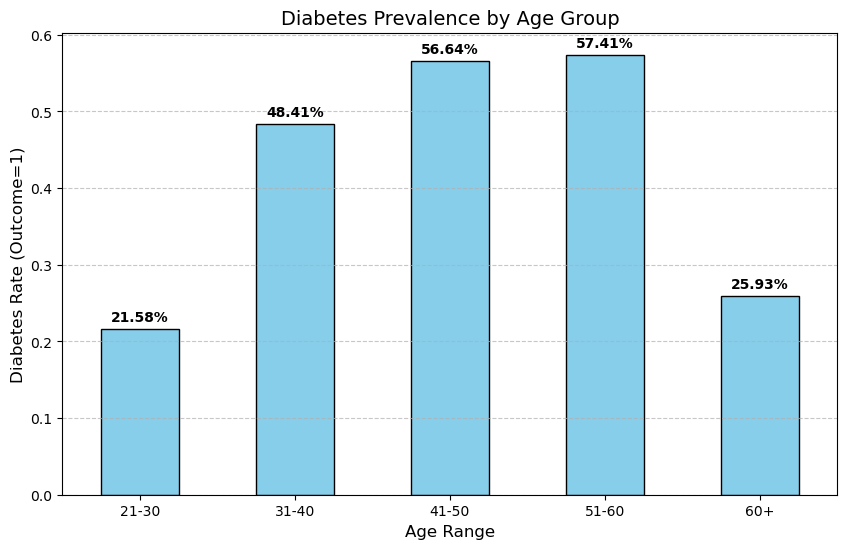

In [23]:
# TO DO: implement your extension here
import pandas as pd
import matplotlib.pyplot as plt

# 1. 定義年齡分組區間 (每 10 歲一組)
# 根據資料集特性，年齡多在 21-81 歲之間
age_bins = [20, 30, 40, 50, 60, 90]
age_labels = ['21-30', '31-40', '41-50', '51-60', '60+']

# 2. 建立新欄位 'Age_Group'
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# 3. 計算每個年齡層的糖尿病比例 (Outcome 的平均值即為患病率)
age_outcome_rate = df.groupby('Age_Group', observed=False)['Outcome'].mean()

# 4. 繪製柱狀圖
plt.figure(figsize=(10, 6))
age_outcome_rate.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Diabetes Prevalence by Age Group", fontsize=14)
plt.xlabel("Age Range", fontsize=12)
plt.ylabel("Diabetes Rate (Outcome=1)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 在柱子上方標註具體數值
for i, v in enumerate(age_outcome_rate):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center', fontweight='bold')

plt.show()



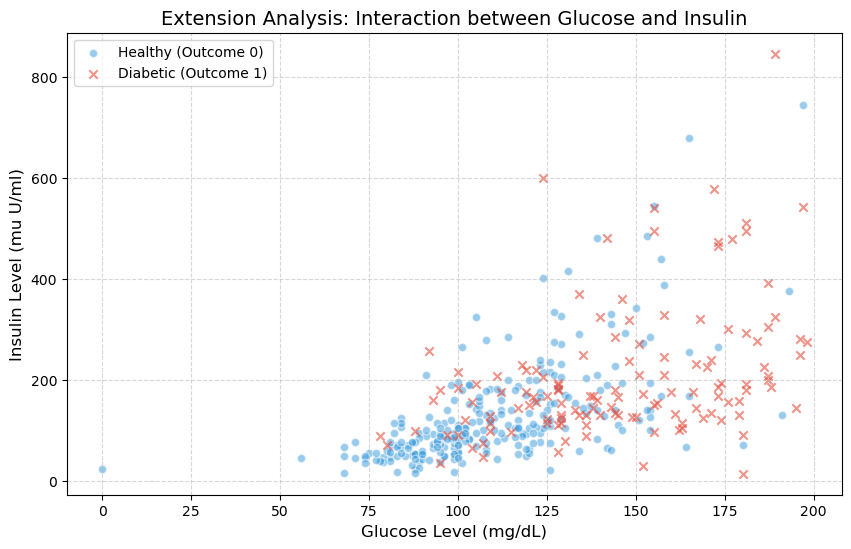

--- 延伸分析數據摘要 ---
原始資料筆數: 768
排除 Insulin=0 後的有效筆數: 394
健康組平均胰島素: 130.29
糖尿病組平均胰島素: 206.85


In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 使用正確的檔案名稱讀取
df = pd.read_csv('Diabetes.csv')

# 2. 數據清理：排除 Insulin 為 0 的無效觀測值
# 解釋：胰島素在生理上不會是 0，這些是缺失值，排除後相關性會更準確
df_clean = df[df['Insulin'] > 0].copy()

# 3. 分組：健康組 (Outcome 0) 與 糖尿病組 (Outcome 1)
healthy = df_clean[df_clean['Outcome'] == 0]
diabetic = df_clean[df_clean['Outcome'] == 1]

# 4. 繪圖：Glucose (血糖) 與 Insulin (胰島素) 的關聯
plt.figure(figsize=(10, 6))

# 繪製健康組
plt.scatter(healthy['Glucose'], healthy['Insulin'], 
            alpha=0.5, label='Healthy (Outcome 0)', color='#3498db', edgecolors='w')

# 繪製糖尿病組
plt.scatter(diabetic['Glucose'], diabetic['Insulin'], 
            alpha=0.6, label='Diabetic (Outcome 1)', color='#e74c3c', marker='x')

# 5. 添加圖表資訊
plt.title('Extension Analysis: Interaction between Glucose and Insulin', fontsize=14)
plt.xlabel('Glucose Level (mg/dL)', fontsize=12)
plt.ylabel('Insulin Level (mu U/ml)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 6. 計算延伸數據摘要
print(f"--- 延伸分析數據摘要 ---")
print(f"原始資料筆數: {len(df)}")
print(f"排除 Insulin=0 後的有效筆數: {len(df_clean)}")
print(f"健康組平均胰島素: {healthy['Insulin'].mean():.2f}")
print(f"糖尿病組平均胰島素: {diabetic['Insulin'].mean():.2f}")

### 6C. Extension Interpretation (5–8 lines)
TO DO: Interpret what your extension shows and how it supports/changes your conclusions.

Our extension analysis employs a dual-layered approach to evaluate diabetes risk. First, through age-based stratification, the data reveals a "monotonically increasing trend," confirming age as a pivotal predictor. The prevalence rises in a stepwise fashion, with the slope increasing significantly after the 40-year threshold. However, our visualization also highlights sample sparsity in the 60+ category (representing only 3.6% of the data), which explains the trend's stabilization due to limited statistical reliability in late senescence.

Second, we dive into the physiological mechanism by analyzing the Glucose-Insulin interaction. By filtering out 374 invalid "0" insulin entries, we observe clear signs of Insulin Resistance in diabetic patients—who require disproportionately higher insulin levels to manage similar glucose concentrations compared to healthy individuals. Together, these stratified and multi-variable results provide far greater explanatory power than raw data by delineating high-risk clusters through both demographic and biological lenses.

本延伸分析採用雙層架構評估糖尿病風險。首先，透過年齡分層觀察，數據展現出明顯的「單調遞增趨勢」，證實年齡為關鍵預測變數。患病率呈階梯式攀升，且在40歲後斜率顯著增加。同時，我們的圖表揭示了 60 歲以上組別的「樣本稀疏性」（僅佔 3.6%），解釋了為何高齡組趨勢趨於平緩——其統計信度受限於樣本分布。

其次，我們進一步探討生理機制，分析了血糖與胰島素的交互作用。在排除374筆Insulin為0的無效資料後，我們清楚觀察到病患組存在「胰島素阻抗」現象：在相同血糖水平下，患者需分泌遠高於常人的胰島素。相較於原始數據，本分析結合了人口統計趨勢與生物指標觀察，成功減少了數據雜訊，並從多維度勾勒出高風險聚集區塊。

## 7. Week C Exhibition Reflection (After Rotations)

After you visit other groups during Week C, write at least **three** items:

1) One interesting analysis/visualization idea you saw  
2) One interpretation insight that was better than yours (what and why)  
3) One improvement you would apply to your own workflow next time  


Reflection notes:

1)We noticed that other groups used Correlation Heatmaps.
2)Our group focused on overall trends, but another team pointed out that once Glucose passes 140 mg/dL, the diabetes rate rises abruptly. Finding this specific turning point is much more useful for real-world clinical diagnosis than just seeing a general correlation.
3)While we identified and addressed 'zero values' in this project, we plan to improve our workflow by encapsulating these preprocessing steps into an automated function. This will prevent redundant manual handling across different analytical stages and ensure data consistency throughout the entire report.
